In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack
import fitsio
# from astropy.io import fits

import mpl_scatter_density
from astropy.visualization.mpl_normalize import ImageNormalize

import healpy as hp

In [2]:
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

plt.rcParams['image.cmap'] = 'jet'

In [3]:
# target_dir = '/Volumes/Samsung T5/tmp/dr9m-sep26-2020'
data_dir = '/Volumes/Samsung T5/tmp/dr9_tests/targets'
randoms_path = '/Volumes/Samsung T5/tmp/dr9m-sep26-2020/0.42.0/randoms/resolve/randoms-1-0.fits'

randoms_density = 5000.
min_nobs = 2

randoms_columns = ['RA', 'DEC',  'NOBS_G', 'NOBS_R', 'NOBS_Z', 'MASKBITS', 'PHOTSYS',
        'GALDEPTH_G', 'GALDEPTH_R', 'GALDEPTH_Z',
        'PSFDEPTH_G', 'PSFDEPTH_R', 'PSFDEPTH_Z', 'PSFDEPTH_W1', 'PSFDEPTH_W2',
        'PSFSIZE_G', 'PSFSIZE_R', 'PSFSIZE_Z', 'EBV']

--------
# North

In [4]:
field = 'north'
if field=='south':
    region = 'S'
else:
    region = 'N'

In [6]:
randoms = Table(fitsio.read(randoms_path, columns=randoms_columns))
print(len(randoms))

63283970


In [7]:
mask = (randoms['NOBS_G']>=min_nobs) & (randoms['NOBS_R']>=min_nobs) & (randoms['NOBS_Z']>=min_nobs)
print(np.sum(mask))
mask &= (randoms['PHOTSYS']==region)
print(np.sum(mask))

randoms = randoms[mask]

56484876
24563668


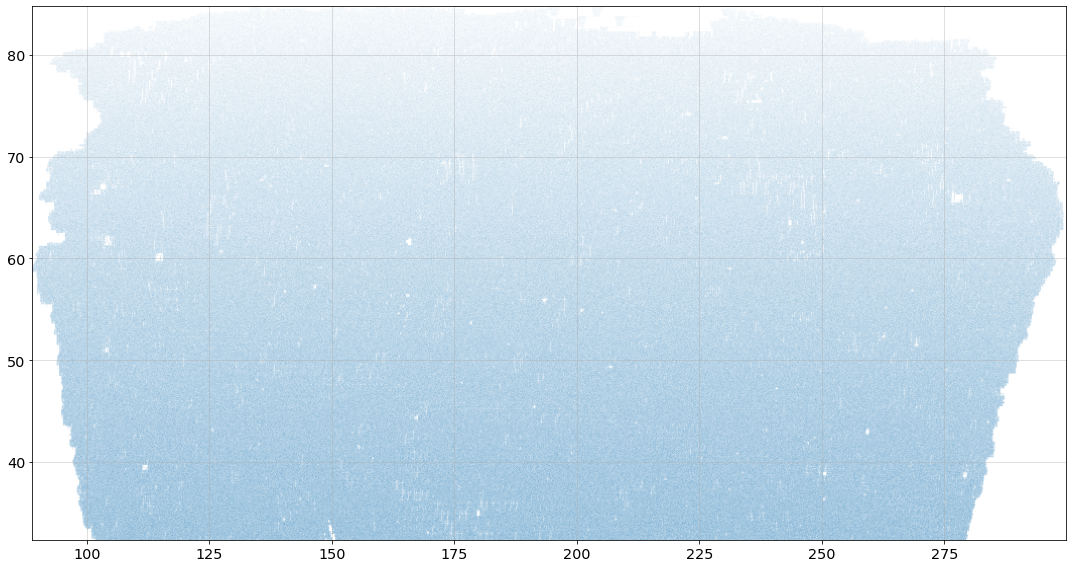

In [15]:
norm = ImageNormalize(vmin=0., vmax=200)
fig = plt.figure(figsize=(15, 8))
ax = fig.add_subplot(1, 1, 1, projection='scatter_density')
ax.scatter_density(randoms['RA'], randoms['DEC'], color='C0', norm=norm)
# ax.axis([310, 80, 30, 85])
ax.grid(alpha=0.5)
plt.tight_layout()
# plt.savefig('plots/tmp_{}_randoms.png'.format(field))
plt.show()

In [16]:
# maskbits = [1, 5, 6, 7, 8, 9, 11, 12, 13]

---------

In [17]:
mask_clean = np.ones(len(randoms), dtype=bool)

In [18]:
maskbits = [5, 6, 7]
for bit in maskbits:
    mask_clean &= (randoms['MASKBITS'] & 2**bit)==0
print('{:.2f}%'.format(np.sum(~mask_clean)/len(mask_clean)*100))

0.00%


In [19]:
maskbits = [12, 13]
for bit in maskbits:
    mask_clean &= (randoms['MASKBITS'] & 2**bit)==0
print('{:.2f}%'.format(np.sum(~mask_clean)/len(mask_clean)*100))

0.19%


In [20]:
maskbits = [1]
for bit in maskbits:
    mask_clean &= (randoms['MASKBITS'] & 2**bit)==0
print('{:.2f}%'.format(np.sum(~mask_clean)/len(mask_clean)*100))

0.91%


In [21]:
maskbits = [11]
for bit in maskbits:
    mask_clean &= (randoms['MASKBITS'] & 2**bit)==0
print('{:.2f}%'.format(np.sum(~mask_clean)/len(mask_clean)*100))

5.20%


In [22]:
maskbits = [8]
for bit in maskbits:
    mask_clean &= (randoms['MASKBITS'] & 2**bit)==0
print('{:.2f}%'.format(np.sum(~mask_clean)/len(mask_clean)*100))

7.34%


In [23]:
maskbits = [9]
for bit in maskbits:
    mask_clean &= (randoms['MASKBITS'] & 2**bit)==0
print('{:.2f}%'.format(np.sum(~mask_clean)/len(mask_clean)*100))

7.43%


---------

In [27]:
mask_clean = np.ones(len(randoms), dtype=bool)

In [28]:
maskbits = [5, 6, 7]
for bit in maskbits:
    mask_clean &= (randoms['MASKBITS'] & 2**bit)==0
print('{:.2f}%'.format(np.sum(~mask_clean)/len(mask_clean)*100))

0.00%


In [29]:
maskbits = [12, 13]
for bit in maskbits:
    mask_clean &= (randoms['MASKBITS'] & 2**bit)==0
print('{:.2f}%'.format(np.sum(~mask_clean)/len(mask_clean)*100))

0.19%


In [30]:
maskbits = [1]
for bit in maskbits:
    mask_clean &= (randoms['MASKBITS'] & 2**bit)==0
print('{:.2f}%'.format(np.sum(~mask_clean)/len(mask_clean)*100))

0.91%


In [31]:
maskbits = [8]
for bit in maskbits:
    mask_clean &= (randoms['MASKBITS'] & 2**bit)==0
print('{:.2f}%'.format(np.sum(~mask_clean)/len(mask_clean)*100))

4.12%


In [32]:
maskbits = [9]
for bit in maskbits:
    mask_clean &= (randoms['MASKBITS'] & 2**bit)==0
print('{:.2f}%'.format(np.sum(~mask_clean)/len(mask_clean)*100))

4.21%


---------

In [33]:
mask_clean = np.ones(len(randoms), dtype=bool)

In [34]:
maskbits = [5, 6, 7]
for bit in maskbits:
    mask_clean &= (randoms['MASKBITS'] & 2**bit)==0
print('{:.2f}%'.format(np.sum(~mask_clean)/len(mask_clean)*100))

0.00%


In [35]:
maskbits = [1]
for bit in maskbits:
    mask_clean &= (randoms['MASKBITS'] & 2**bit)==0
print('{:.2f}%'.format(np.sum(~mask_clean)/len(mask_clean)*100))

0.72%


In [36]:
maskbits = [11]
for bit in maskbits:
    mask_clean &= (randoms['MASKBITS'] & 2**bit)==0
print('{:.2f}%'.format(np.sum(~mask_clean)/len(mask_clean)*100))

5.01%


In [22]:
maskbits = [8]
for bit in maskbits:
    mask_clean &= (randoms['MASKBITS'] & 2**bit)==0
print('{:.2f}%'.format(np.sum(~mask_clean)/len(mask_clean)*100))

7.34%


In [23]:
maskbits = [9]
for bit in maskbits:
    mask_clean &= (randoms['MASKBITS'] & 2**bit)==0
print('{:.2f}%'.format(np.sum(~mask_clean)/len(mask_clean)*100))

7.43%
